In [113]:
print("START")

START


# Telecom Churn Prediction System

## Problem Definition
- Customer churn is a major problem and one of the most important concerns for large companies. Due to the direct effect on the revenues of the companies, especially in the telecom field, companies are seeking to develop means to predict potential customer to churn. Therefore, finding factors that increase customer churn is important to take necessary actions to reduce this churn.

## Problem Solution
- Here, we are going to build a prediction system that predicts whether the user is likely to churn or stay.
We are going to use a classification model by training multiple models and choose the best one.

Here are the models we are going to train;
- LogisticRegression
- KNNClassifier
- RandomForestClassifier
- XGBoostClassifier
- CatBoostClassifier
- LGBMClassifier
- BalancedRandomForestClassifier

## Evaluation Metrics
In churn prediction, Overall Accuracy is a trap. If 90% of your customers stay, a dummy model that predicts "No Churn" for everyone is 90% accurate but completely useless. We should evaluate our models using:

    Recall (Sensitivity): Out of all the actual churning customers, how many did your model catch? (Crucial because missing a churning customer costs revenue).

    Precision: Out of all the customers predicted to churn, how many actually did? (Crucial because offering discounts/incentives to customers who weren't going to leave wastes budget).

    F1-Score / PR-AUC: The harmonic mean of Precision and Recall. The Precision-Recall Area Under Curve (PR-AUC) is much more informative than ROC-AUC for highly imbalanced datasets.

### Optimization Pipeline
Instead of relying on default parameters, we will define a focused hyperparameter grid for each distinct model family. We will use stratified cross-validation paired with `GridSearchCV` (or `RandomizedSearchCV`) to isolate the optimal configuration for each architecture before final comparison.

## Post-Modeling: Explainability (The "Why")

A telecom company won't just want a list of binary predictions; they need to know why a customer is flagged.

    SHAP (SHapley Additive exPlanations): Add SHAP to your project to get global feature importance (e.g., "Total International Charges is the top driving factor for churn across the company") and local explanations (e.g., "Customer X was flagged because their contract changed to Month-to-Month and data usage dropped by 40%").

    We are going to document the model by using SHAP explainations.

Let's start.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

Let's get the data

In [3]:
data = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Let's see how many female and male in the data who is likely to churn or stay.

gender  Churn
Female  No       73.079128
        Yes      26.920872
Male    No       73.839662
        Yes      26.160338
Name: proportion, dtype: float64


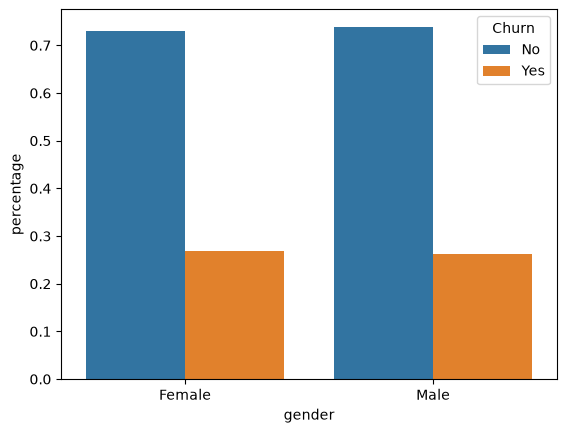

In [87]:
df_perc = data.groupby(['gender'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
sns.barplot(data=df_perc, x='gender', y='percentage', hue='Churn')

print(data.groupby('gender')['Churn'].value_counts(normalize=True) * 100)

As we can see, there is no distinguishable feature between genders.

---

Let's see the SeniorCitizen feature

SeniorCitizen  Churn
0              No       76.393832
               Yes      23.606168
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64


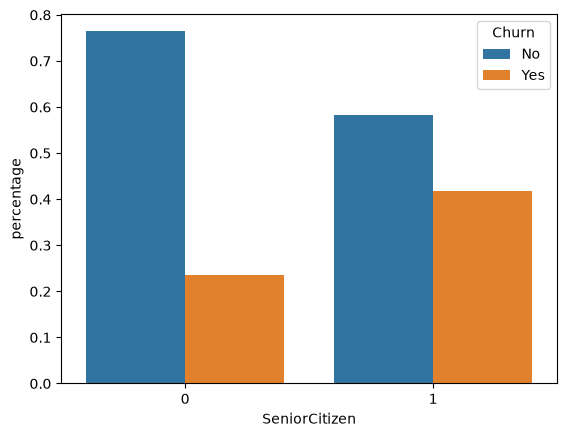

In [90]:
df_perc = data.groupby(['SeniorCitizen'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
sns.barplot(data=df_perc, x='SeniorCitizen', y='percentage', hue='Churn')

print(data.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True) * 100)

Looks like the senior citizen's is more likely to churn than the not senior citizen's people

---

Let's see the people that has partner or does not have partner is doing with the Churn feature

Partner  Churn
No       No       67.042021
         Yes      32.957979
Yes      No       80.335097
         Yes      19.664903
Name: proportion, dtype: float64


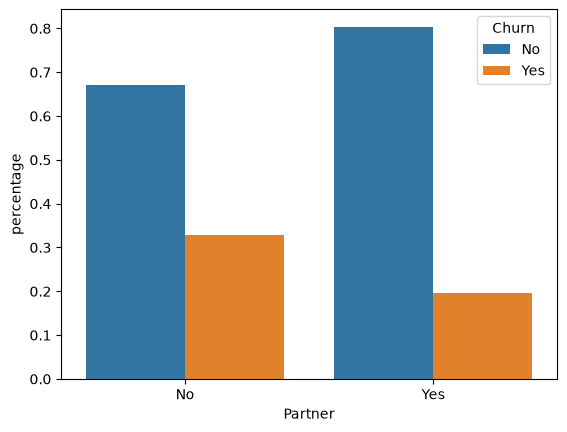

In [91]:
df_perc = data.groupby(['Partner'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
sns.barplot(data=df_perc, x='Partner', y='percentage', hue='Churn')

print(data.groupby('Partner')['Churn'].value_counts(normalize=True) * 100)

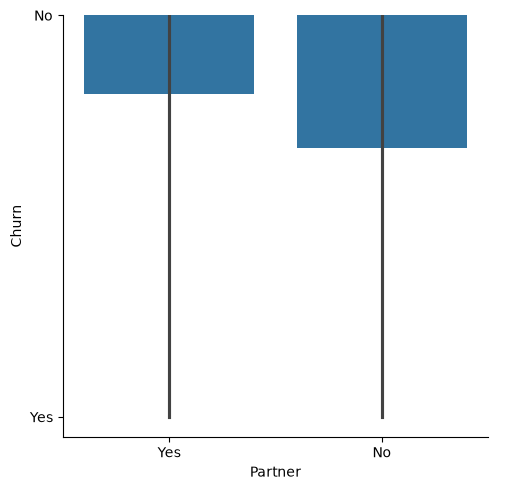

In [93]:
sns.catplot(data=data, x="Partner", y="Churn", errorbar=("pi", 95), kind="bar")

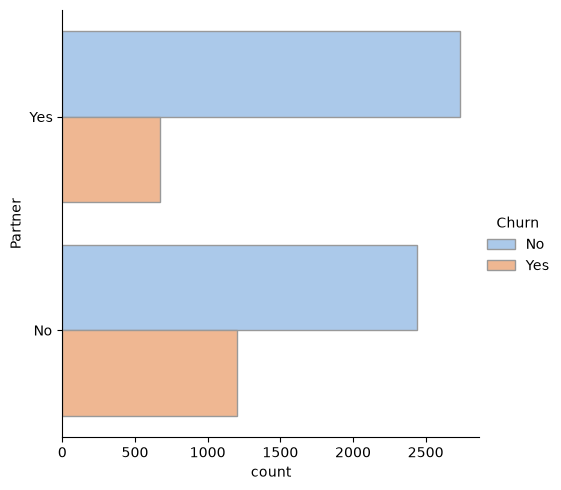

In [94]:
sns.catplot(
    data=data, y="Partner", hue="Churn", kind="count",
    palette="pastel", edgecolor=".6"
)

Oh, we can see that the people who does not have a partner is more likely to churn than the people who has a partner

---

Let's check the dependents feature

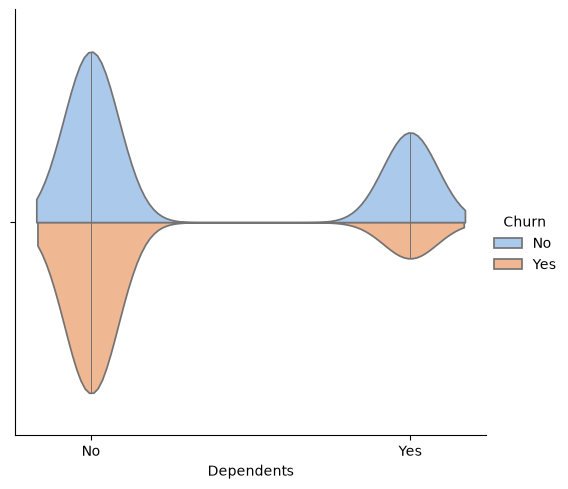

In [41]:
sns.catplot(
    data=data, x="Dependents", hue="Churn",
    kind="violin", inner="stick", split=True, palette="pastel",
)

Dependents  Churn
No          No       68.720860
            Yes      31.279140
Yes         No       84.549763
            Yes      15.450237
Name: proportion, dtype: float64


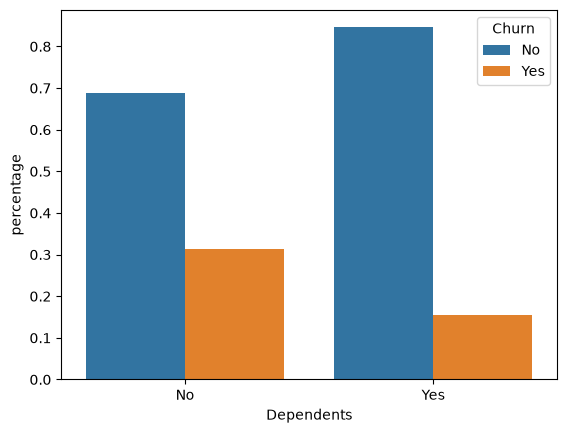

In [95]:
df_perc = data.groupby(['Dependents'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
sns.barplot(data=df_perc, x='Dependents', y='percentage', hue='Churn')

print(data.groupby('Dependents')['Churn'].value_counts(normalize=True) * 100)

 We are clearly seeing the people who does not have a dependents is more likely to churn than the people who has a dependents

---

Let's move on to the tenure feature

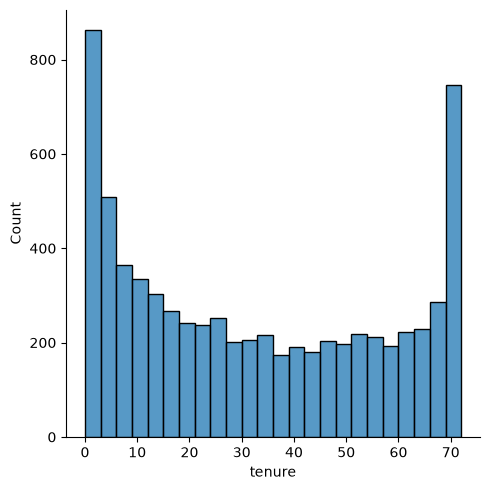

In [43]:
sns.displot(data, x="tenure", binwidth=3)

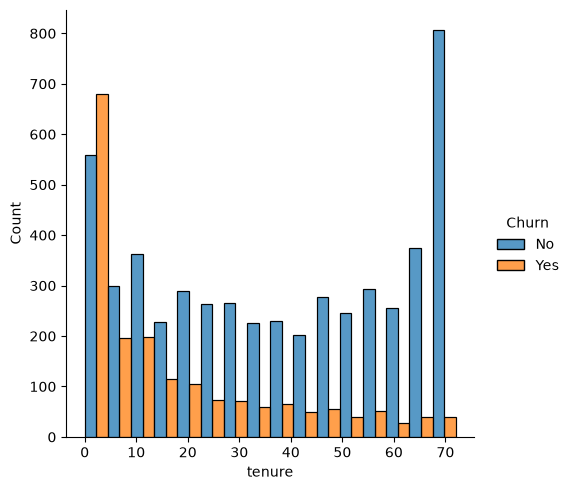

In [60]:
sns.displot(data, x="tenure", hue="Churn", multiple="dodge")

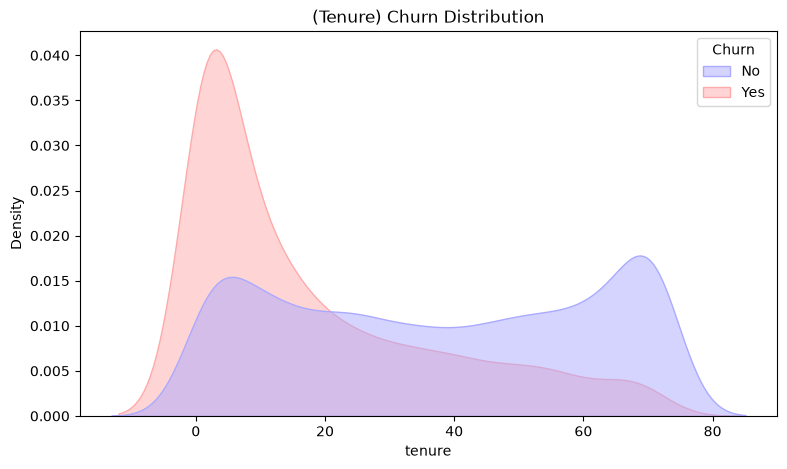

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.kdeplot(data=data, x="tenure", hue="Churn", fill=True, common_norm=False, palette="bwr", alpha=0.5)
plt.title("(Tenure) Churn Distribution")
plt.show()

We can see that the people who is with the company for between 0-5 month is more likely to churn than the people who is with the company more than 5 months.

And the people who is with the company almost 50-70 month is more likely to stay with the company

---

Let's look at the all feature that is about the service

In [61]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

PhoneService  Churn
No            No       75.073314
              Yes      24.926686
Yes           No       73.290363
              Yes      26.709637
Name: proportion, dtype: float64


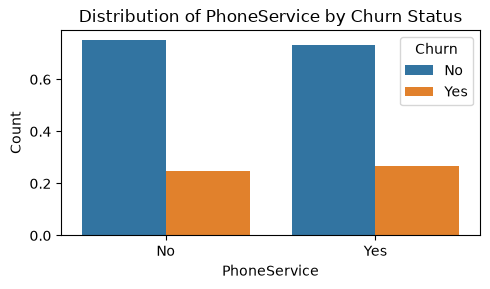

MultipleLines     Churn
No                No       74.955752
                  Yes      25.044248
No phone service  No       75.073314
                  Yes      24.926686
Yes               No       71.390104
                  Yes      28.609896
Name: proportion, dtype: float64


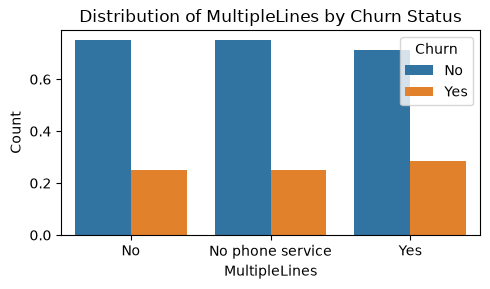

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64


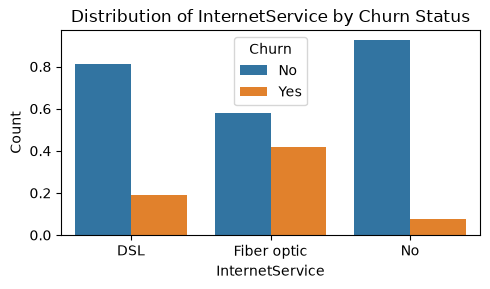

OnlineSecurity       Churn
No                   No       58.233276
                     Yes      41.766724
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       85.388806
                     Yes      14.611194
Name: proportion, dtype: float64


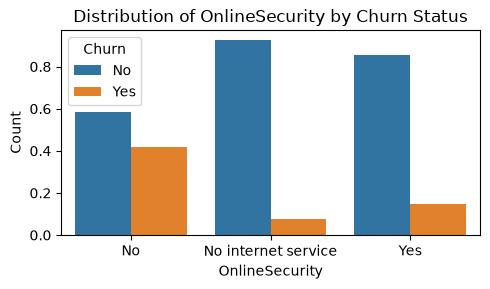

OnlineBackup         Churn
No                   No       60.071244
                     Yes      39.928756
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       78.468506
                     Yes      21.531494
Name: proportion, dtype: float64


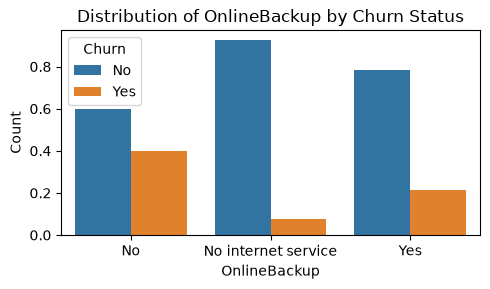

DeviceProtection     Churn
No                   No       60.872375
                     Yes      39.127625
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       77.497936
                     Yes      22.502064
Name: proportion, dtype: float64


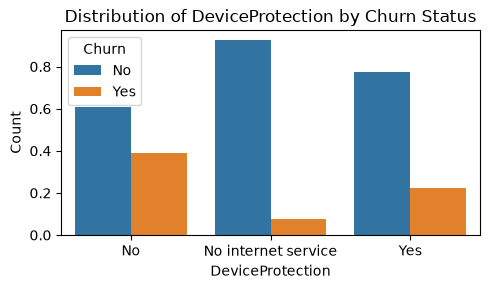

TechSupport          Churn
No                   No       58.364526
                     Yes      41.635474
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       84.833659
                     Yes      15.166341
Name: proportion, dtype: float64


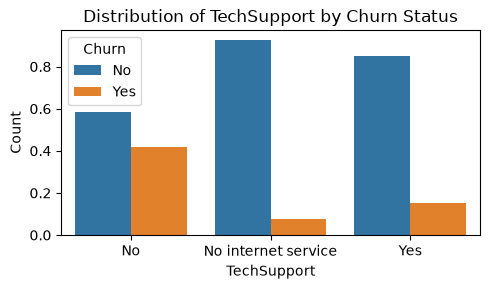

StreamingTV          Churn
No                   No       66.476868
                     Yes      33.523132
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       69.929812
                     Yes      30.070188
Name: proportion, dtype: float64


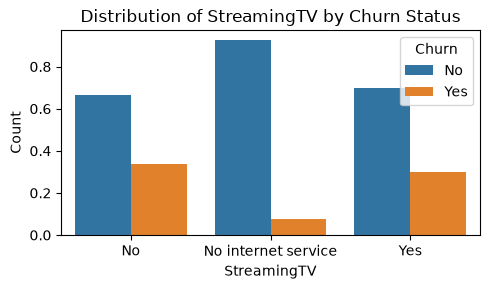

StreamingMovies      Churn
No                   No       66.319569
                     Yes      33.680431
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       70.058565
                     Yes      29.941435
Name: proportion, dtype: float64


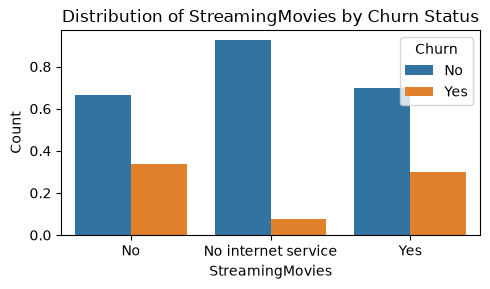

In [85]:
service_cols = ["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

for col in service_cols: 
    plt.figure(figsize=(5, 3))
    df_perc = data.groupby([col])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
    sns.barplot(data=df_perc, x=f'{col}', y='percentage', hue='Churn')
    print(data.groupby(col)['Churn'].value_counts(normalize=True) * 100)
    plt.title(f"Distribution of {col} by Churn Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Telecom Services Insights (Quick Summary)

* **Weak Predictors:** `PhoneService`, `MultipleLines`, `StreamingTV`, and `StreamingMovies` show flat churn rates (~25%-33%) across categories. They offer weak predictive signals.
* **Strong Predictors:** * `InternetService`: Fiber Optic has a massive **41.89%** churn rate compared to DSL (18.95%). Highly critical feature.
  * `OnlineSecurity` & `TechSupport`: Missing these services spikes churn to **~41%**, while having them drops it to **~15%**. They act as retention anchors.
  * `OnlineBackup` & `DeviceProtection`: No services = **~39%** churn; Yes = **~21%** churn.

**Pipeline & Feature Engineering Actions:**
1. Keep all features for encoding; preserve `"No internet service"` as a structural category.
2. **New Feature Idea:** Create `Total_Utility_Services` by summing up active security, backup, protection, and support subscriptions. Churn should decrease linearly as this count increases.

---

Let's see the Contract

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64


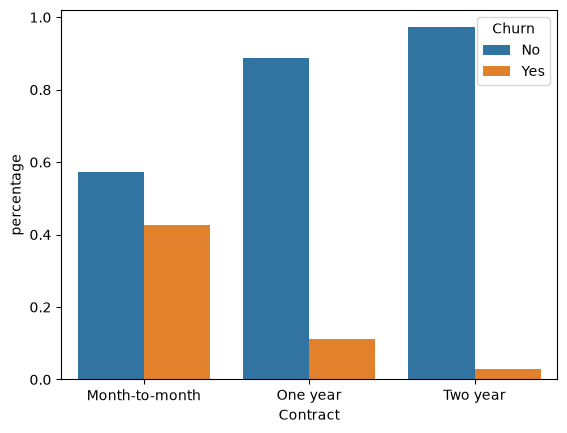

In [98]:
# Shows percentage instead of absolute numbers
df_perc = data.groupby(['Contract'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
sns.barplot(data=df_perc, x='Contract', y='percentage', hue='Churn')

print(data.groupby('Contract')['Churn'].value_counts(normalize=True) * 100)

The people has a month-to-month contract is more like to churn than the one-year contract and two year contract

And One-year contract people is more likely to churn than the two year contract people

---

Let's see the paperless billing feature

In [78]:
data.PaperlessBilling.value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

<Axes: xlabel='PaperlessBilling', ylabel='percentage'>

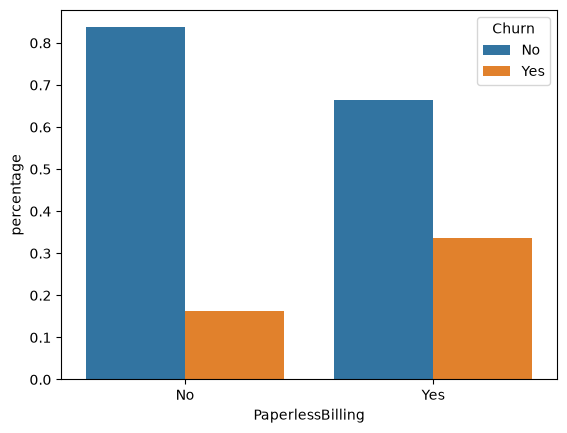

In [79]:
df_perc = data.groupby(['PaperlessBilling'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
sns.barplot(data=df_perc, x='PaperlessBilling', y='percentage', hue='Churn')

In [80]:
# Calculate the exact churn rates per category
print(data.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True) * 100)

PaperlessBilling  Churn
No                No       83.669916
                  Yes      16.330084
Yes               No       66.434908
                  Yes      33.565092
Name: proportion, dtype: float64


The people has a paperlessbilling is 2x more likely to churn than the people who does not have a paperlessbilling

---

Let's check PaymentMethod 

In [99]:
data.PaymentMethod.value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64


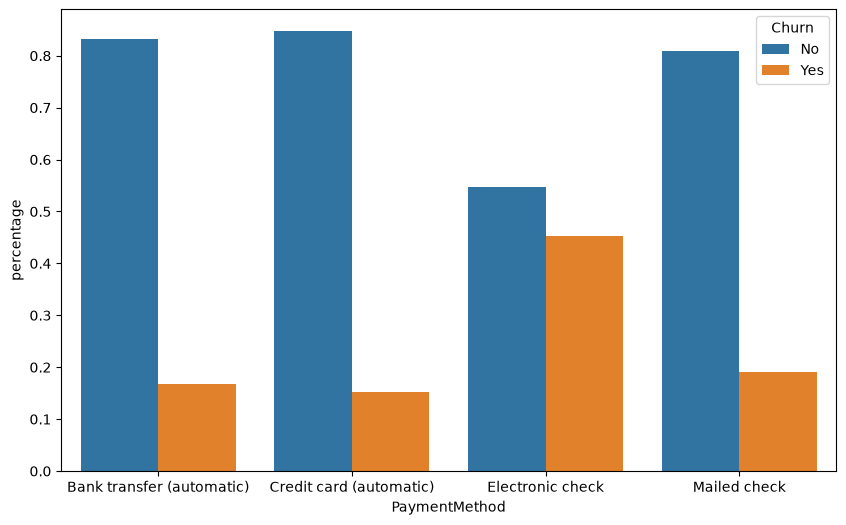

In [103]:
df_perc = data.groupby(['PaymentMethod'])['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_perc, x='PaymentMethod', y='percentage', hue='Churn')

print(data.groupby(['PaymentMethod'])['Churn'].value_counts(normalize=True) * 100)

* **Electronic Check Crisis:** Customers paying with an `Electronic check` have a staggering churn rate of **45.29%**. Nearly half of them leave the company.
* **Automated Stability:** Customers using automated methods (`Credit card` at **15.24%** or `Bank transfer` at **16.71%**) are highly loyal and stay with the company. 
* **Mailed Check:** Traditional paper check users also remain relatively stable with a low **19.11%**

/tmp/ipykernel_281567/2311443498.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Churn", y="MonthlyCharges", palette="Set2", ax=axes[1])


Text(0.5, 1.0, 'Monthly Charges Range by Churn Status')

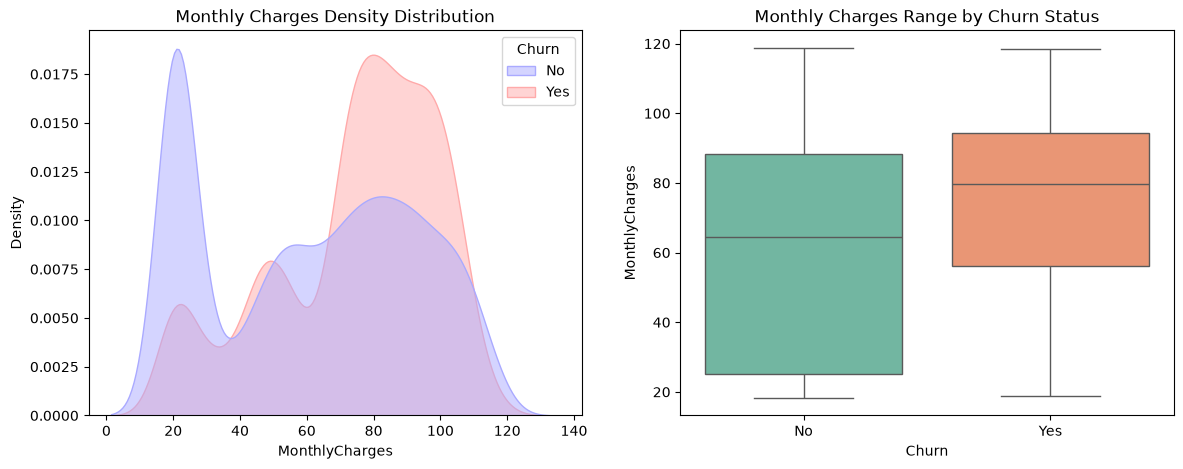

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=data, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False, palette="bwr", alpha=0.5, ax=axes[0])
axes[0].set_title("Monthly Charges Density Distribution")

# 2. Box Plot (Shows median and quartiles cleanly)
sns.boxplot(data=data, x="Churn", y="MonthlyCharges", palette="Set2", ax=axes[1])
axes[1].set_title("Monthly Charges Range by Churn Status")

**The Low-Cost Safe Haven**: Look at the massive blue peak on the left of the KDE plot around $20. Customers paying very low monthly rates (likely basic phone-only plans or no-internet users) are highly loyal and almost never churn.

**The High-Cost Risk Zone**: Look at the massive red peak between  70 and  100 USD. Churning customers are heavily concentrated in this premium price tier.

**The Statistical Confirmation (Box Plot)**: * Retained customers (Churn = No) have a much lower median bill (around $65) and their costs are widely spread out.

   - Churning customers (Churn = Yes) have a much higher median bill (around 80 USD), and 75% of them are paying over $55.

In [110]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'].replace(' ', np.nan))
data["TotalCharges"] = data["TotalCharges"].astype(float)

/tmp/ipykernel_281567/809079067.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Churn", y="TotalCharges", palette="Set2", ax=axes[1])


Text(0.5, 1.0, 'Total Charges Range by Churn Status')

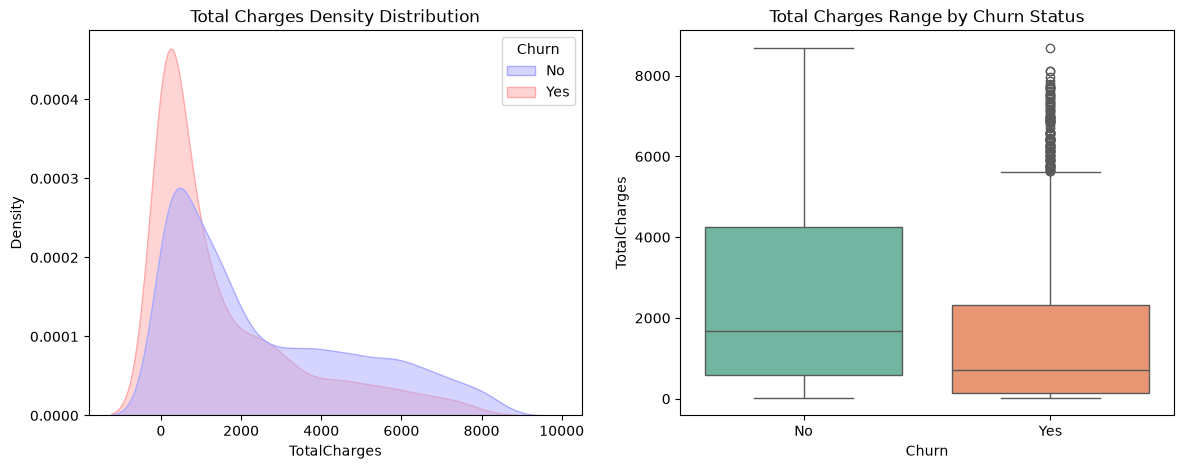

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=data, x="TotalCharges", hue="Churn", fill=True, common_norm=False, palette="bwr", alpha=0.5, ax=axes[0])
axes[0].set_title("Total Charges Density Distribution")

# 2. Box Plot (Shows median and quartiles cleanly)
sns.boxplot(data=data, x="Churn", y="TotalCharges", palette="Set2", ax=axes[1])
axes[1].set_title("Total Charges Range by Churn Status")

In [112]:
print(f"Missing values in TotalCharges: {data['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges: 11


### Total Charges vs. Churn Insights

* **The Early Attrition Spike:** The KDE plot shows an extreme red peak for `Churn = Yes` right near **0 to 500 USD**. This means the vast majority of people who leave the company do so very early on, before they can accumulate a high lifetime bill.
* **The Long-Term Loyalty Gap:** As total charges increase past **2,000 USD**, the red line drops significantly below the blue line. Customers who have spent thousands of dollars with the company are heavily locked in and rarely leave.
* **Outliers (Box Plot):** The individual points (outliers) on the `Churn = Yes` box plot around **6,000–8,000 USD** represent rare cases—long-term, high-value customers who suddenly decided to churn.

**Data Cleaning Note:**
* Found **11 missing values** in `TotalCharges`. These correspond to new customers with `tenure = 0` who have not yet received their first bill. 

**Pipeline Action:** Keep this as a raw continuous feature, but fill the 11 missing values with `0` since no tenure means zero charges accumulated.

---

# FINAL REPORT

# Customer Churn Exploratory Data Analysis (EDA) Report

## 1. Introduction

The objective of this exploratory data analysis (EDA) is to understand the characteristics of customers who are more likely to churn and identify the most influential variables before building predictive machine learning models.

The analysis investigates demographic information, customer tenure, subscribed services, billing behavior, and payment preferences to uncover patterns associated with customer retention and customer churn.

---

# 2. Demographic Analysis

## Gender

The distribution of churn is nearly identical between male and female customers.

### Key Insight

- Gender does not appear to influence customer churn.
- It is expected to have very low predictive power for the machine learning model.

---

## Senior Citizen

| Senior Citizen | Churn Rate |
|---------------|-----------:|
| No | 23.61% |
| Yes | 41.68% |

Senior citizens are significantly more likely to leave the company than younger customers.

### Key Insight

- Being a senior citizen is associated with substantially higher churn risk.
- This variable should be retained as an important predictive feature.

---

## Partner

| Partner | Churn Rate |
|----------|-----------:|
| No | 32.96% |
| Yes | 19.66% |

Customers without a partner are considerably more likely to churn.

### Key Insight

Having a partner appears to improve customer retention, suggesting that customers with more stable household situations remain with the company longer.

---

## Dependents

| Dependents | Churn Rate |
|-------------|-----------:|
| No | 31.28% |
| Yes | 15.45% |

Customers without dependents churn at approximately twice the rate of customers who have dependents.

### Key Insight

Having dependents is strongly associated with customer loyalty.

---

# 3. Customer Lifetime (Tenure)

Tenure is one of the strongest indicators of churn.

### Observations

- Customers within their first **0–5 months** have the highest churn rate.
- Churn steadily decreases as tenure increases.
- Customers staying **50–70 months** are highly loyal and rarely leave.

### Business Insight

Most customer losses occur during the onboarding period. Once customers remain with the company for a longer period, they become increasingly loyal.

---

# 4. Telecom Services Analysis

## Phone Service

| Phone Service | Churn Rate |
|---------------|-----------:|
| No | 24.93% |
| Yes | 26.71% |

Only a very small difference exists between the two groups.

### Conclusion

Phone service is a weak predictor of churn.

---

## Multiple Lines

| Multiple Lines | Churn Rate |
|----------------|-----------:|
| No | 25.04% |
| No phone service | 24.93% |
| Yes | 28.61% |

Multiple lines show only minor variation.

### Conclusion

This feature contributes little predictive information by itself.

---

## Internet Service

| Internet Service | Churn Rate |
|-----------------|-----------:|
| No | 7.40% |
| DSL | 18.96% |
| Fiber Optic | 41.89% |

Internet service type is one of the strongest predictors in the dataset.

### Key Findings

- Fiber optic customers experience extremely high churn.
- DSL customers are much more stable.
- Customers without internet service rarely churn.

---

## Online Security

| Online Security | Churn Rate |
|----------------|-----------:|
| No | 41.77% |
| Yes | 14.61% |
| No internet service | 7.40% |

Customers without online security are nearly three times more likely to churn.

### Interpretation

Online security acts as a strong customer retention service.

---

## Online Backup

| Online Backup | Churn Rate |
|---------------|-----------:|
| No | 39.93% |
| Yes | 21.53% |
| No internet service | 7.40% |

Customers purchasing online backup are significantly less likely to leave.

---

## Device Protection

| Device Protection | Churn Rate |
|------------------|-----------:|
| No | 39.13% |
| Yes | 22.50% |
| No internet service | 7.40% |

Device protection follows a pattern similar to online backup.

---

## Tech Support

| Tech Support | Churn Rate |
|--------------|-----------:|
| No | 41.64% |
| Yes | 15.17% |
| No internet service | 7.40% |

Technical support is among the strongest retention features in the dataset.

Customers without technical support churn nearly three times more frequently.

---

## Streaming TV

| Streaming TV | Churn Rate |
|--------------|-----------:|
| No | 33.52% |
| Yes | 30.07% |
| No internet service | 7.40% |

Streaming TV shows only a modest relationship with churn.

---

## Streaming Movies

| Streaming Movies | Churn Rate |
|------------------|-----------:|
| No | 33.68% |
| Yes | 29.94% |
| No internet service | 7.40% |

Streaming Movies behaves similarly to Streaming TV and provides limited predictive value.

---

## Telecom Services Summary

### Weak Predictors

The following services exhibit relatively flat churn distributions:

- PhoneService
- MultipleLines
- StreamingTV
- StreamingMovies

These features provide limited predictive information individually.

### Strong Predictors

The most informative telecom-related variables are:

- InternetService
- OnlineSecurity
- TechSupport
- OnlineBackup
- DeviceProtection

These services show substantial differences in churn rates and are expected to be highly valuable for predictive modeling.

### Feature Engineering Opportunity

A new feature can be constructed:

**Total_Utility_Services**

This feature represents the total number of subscribed value-added services:

- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport

Customers with more subscribed utility services are expected to exhibit lower churn rates. This engineered feature may improve model performance by summarizing overall customer engagement.

---

# 5. Contract Analysis

## Contract Type

| Contract | Churn Rate |
|-----------|-----------:|
| Month-to-month | 42.71% |
| One year | 11.27% |
| Two year | 2.83% |

Contract length is one of the strongest predictors of customer churn.

### Key Findings

- Month-to-month customers are the most likely to churn.
- One-year contracts significantly improve customer retention.
- Two-year contracts demonstrate exceptional customer loyalty with only a 2.83% churn rate.

### Business Insight

Long-term contracts create strong customer commitment and dramatically reduce churn.

---

# 6. Billing Analysis

## Paperless Billing

| Paperless Billing | Churn Rate |
|------------------|-----------:|
| No | 16.33% |
| Yes | 33.57% |

Customers using paperless billing churn at approximately twice the rate of customers receiving paper bills.

### Key Insight

Paperless billing is associated with substantially higher churn risk.

---

## Payment Method

| Payment Method | Churn Rate |
|----------------|-----------:|
| Credit Card (Automatic) | 15.24% |
| Bank Transfer (Automatic) | 16.71% |
| Mailed Check | 19.11% |
| Electronic Check | 45.29% |

### Key Findings

**Electronic Check Crisis**

Customers paying through electronic checks exhibit the highest churn rate in the dataset. Nearly half of these customers leave the company.

**Automated Payment Stability**

Customers using automatic payment methods (credit cards and bank transfers) show excellent retention and the lowest churn rates.

**Mailed Check**

Customers paying by mailed check also demonstrate relatively strong loyalty.

---

# 7. Monthly Charges Analysis

Monthly charges show a strong relationship with customer churn.

### Key Findings

#### Low-Cost Safe Haven

Customers paying approximately **USD 20 per month** are highly loyal and rarely churn. These customers likely subscribe to basic phone services or have no internet service.

#### High-Cost Risk Zone

Most churning customers pay between **USD 70** and **USD 100** per month, indicating that premium-priced plans experience the highest churn risk.

#### Statistical Confirmation

The box plot supports these observations:

- Retained customers have a lower median monthly charge (approximately **USD 65**).
- Churning customers have a higher median monthly charge (approximately **USD 80**).
- Approximately 75% of churning customers pay more than **USD 55** per month.

### Business Insight

Higher monthly costs are strongly associated with increased churn probability.

---

# 8. Total Charges Analysis

Total charges represent the customer's accumulated lifetime spending with the company.

### Key Findings

#### Early Attrition Spike

The KDE plot shows a large concentration of churning customers with total charges between **USD 0** and **USD 500**.

This indicates that most customers leave very early before accumulating substantial lifetime value.

#### Long-Term Loyalty

As total charges exceed approximately **\$2,000**, churn becomes increasingly uncommon.

Customers with higher lifetime spending are substantially more loyal.

#### Outliers

A small number of high-value customers with total charges between **USD 6,000** and **USD 8,000** still churn.

Although rare, these customers represent valuable accounts that may require targeted retention strategies.

---

## Data Cleaning

During data inspection, **11 missing values** were identified in the `TotalCharges` feature.

Investigation revealed that these customers have:

- `Tenure = 0`
- Newly joined customers
- No generated bill yet

### Pipeline Action

Fill these missing values with **0**, since zero tenure naturally implies zero accumulated charges.

---

# 9. Feature Engineering Recommendations

The following engineered features are recommended before model training:

### Total_Utility_Services

The total number of active value-added services:

- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport

Expected outcome:

- Higher values should correlate with lower churn probability.

Additional potential engineered features include:

- Average Monthly Spend (`TotalCharges / (Tenure + 1)`)
- High Monthly Charge Flag
- Long-Term Customer Indicator
- Automatic Payment Indicator
- Premium Internet Customer Indicator

---

# 10. Overall Conclusions

The exploratory data analysis reveals several strong predictors of customer churn.

### Strong Predictors

- Contract Type
- Tenure
- Internet Service
- Online Security
- Tech Support
- Online Backup
- Device Protection
- Payment Method
- Monthly Charges
- Total Charges
- Senior Citizen
- Partner
- Dependents

### Weak Predictors

- Gender
- Phone Service
- Multiple Lines
- Streaming TV
- Streaming Movies

### Business Recommendations

- Focus retention efforts on customers during their first five months.
- Encourage customers to transition from month-to-month contracts to longer-term agreements.
- Promote automatic payment methods instead of electronic checks.
- Bundle value-added services such as Online Security and Tech Support to improve customer retention.
- Closely monitor customers with high monthly bills, especially Fiber Optic subscribers, as they represent the highest-risk customer segment.


In [114]:
print("END")

END
